<a href="https://colab.research.google.com/github/tentorifrancescaDev/spambase-detection-ml/blob/main/Progetto_SpamBase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Progetto Machine Learning sul dataset Spambase

##Importazione Dataset

In [1]:
!pip install ucimlrepo

In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from time import time

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score

Importiamo il dataset

In [3]:
spambase = fetch_ucirepo(id=94)

X = spambase.data.features
y = spambase.data.targets

#Costruisco il DataFrame unificato per l'EDA, unendo alle feature la colonna target (Class)
df = X.copy()
df['Class'] = y.iloc[:, 0]

print(df.head())

   word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0            0.00               0.64           0.64           0.0   
1            0.21               0.28           0.50           0.0   
2            0.06               0.00           0.71           0.0   
3            0.00               0.00           0.00           0.0   
4            0.00               0.00           0.00           0.0   

   word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0           0.32            0.00              0.00                0.00   
1           0.14            0.28              0.21                0.07   
2           1.23            0.19              0.19                0.12   
3           0.63            0.00              0.31                0.63   
4           0.63            0.00              0.31                0.63   

   word_freq_order  word_freq_mail  ...  char_freq_;  char_freq_(  \
0             0.00            0.00  ...         0.00        0.000   
1 

Guardiamo da quante righe e colonne è formato il dataset

In [4]:
df.shape

(4601, 58)

##Data Exploration


Controlliamo se all'interno del Dataset sono presenti dei valori nulli

In [5]:
df.isnull().sum()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0
word_freq_over,0
word_freq_remove,0
word_freq_internet,0
word_freq_order,0
word_freq_mail,0


Come possiamo vedere dalla tabella non ci sono dati nulli nel dataset

### Analisi e distribuzione della classe target


Controlliamo qual è la classe maggioritaria nel dataset, così da assegnare la label corretta nel seguente grafico a torta

In [6]:
df['Class'].value_counts()

,count
Class,
0,2788
1,1813


0 = email non di Spam <br>
1 = email di Spam

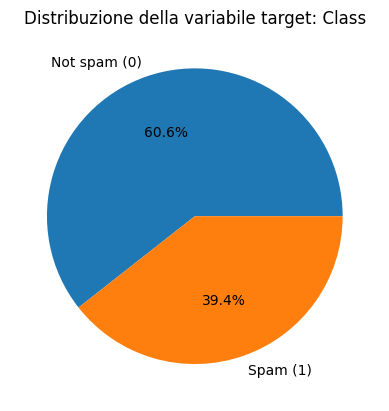

In [7]:
plt.pie(df['Class'].value_counts(), labels=['Not spam (0)', 'Spam (1)'], autopct='%1.1f%%')
plt.title('Distribuzione della variabile target: Class')

plt.show()

C'è un leggero sbilanciamento a favore dei casi di 'Not Spam'

### Analisi del potere discriminante delle feature

I boxplot per feature vs target ci permettono di valutare visivamente il potere discriminante di ciascuna feature rispetto alla variabile target, prima di procedere con la feature selection

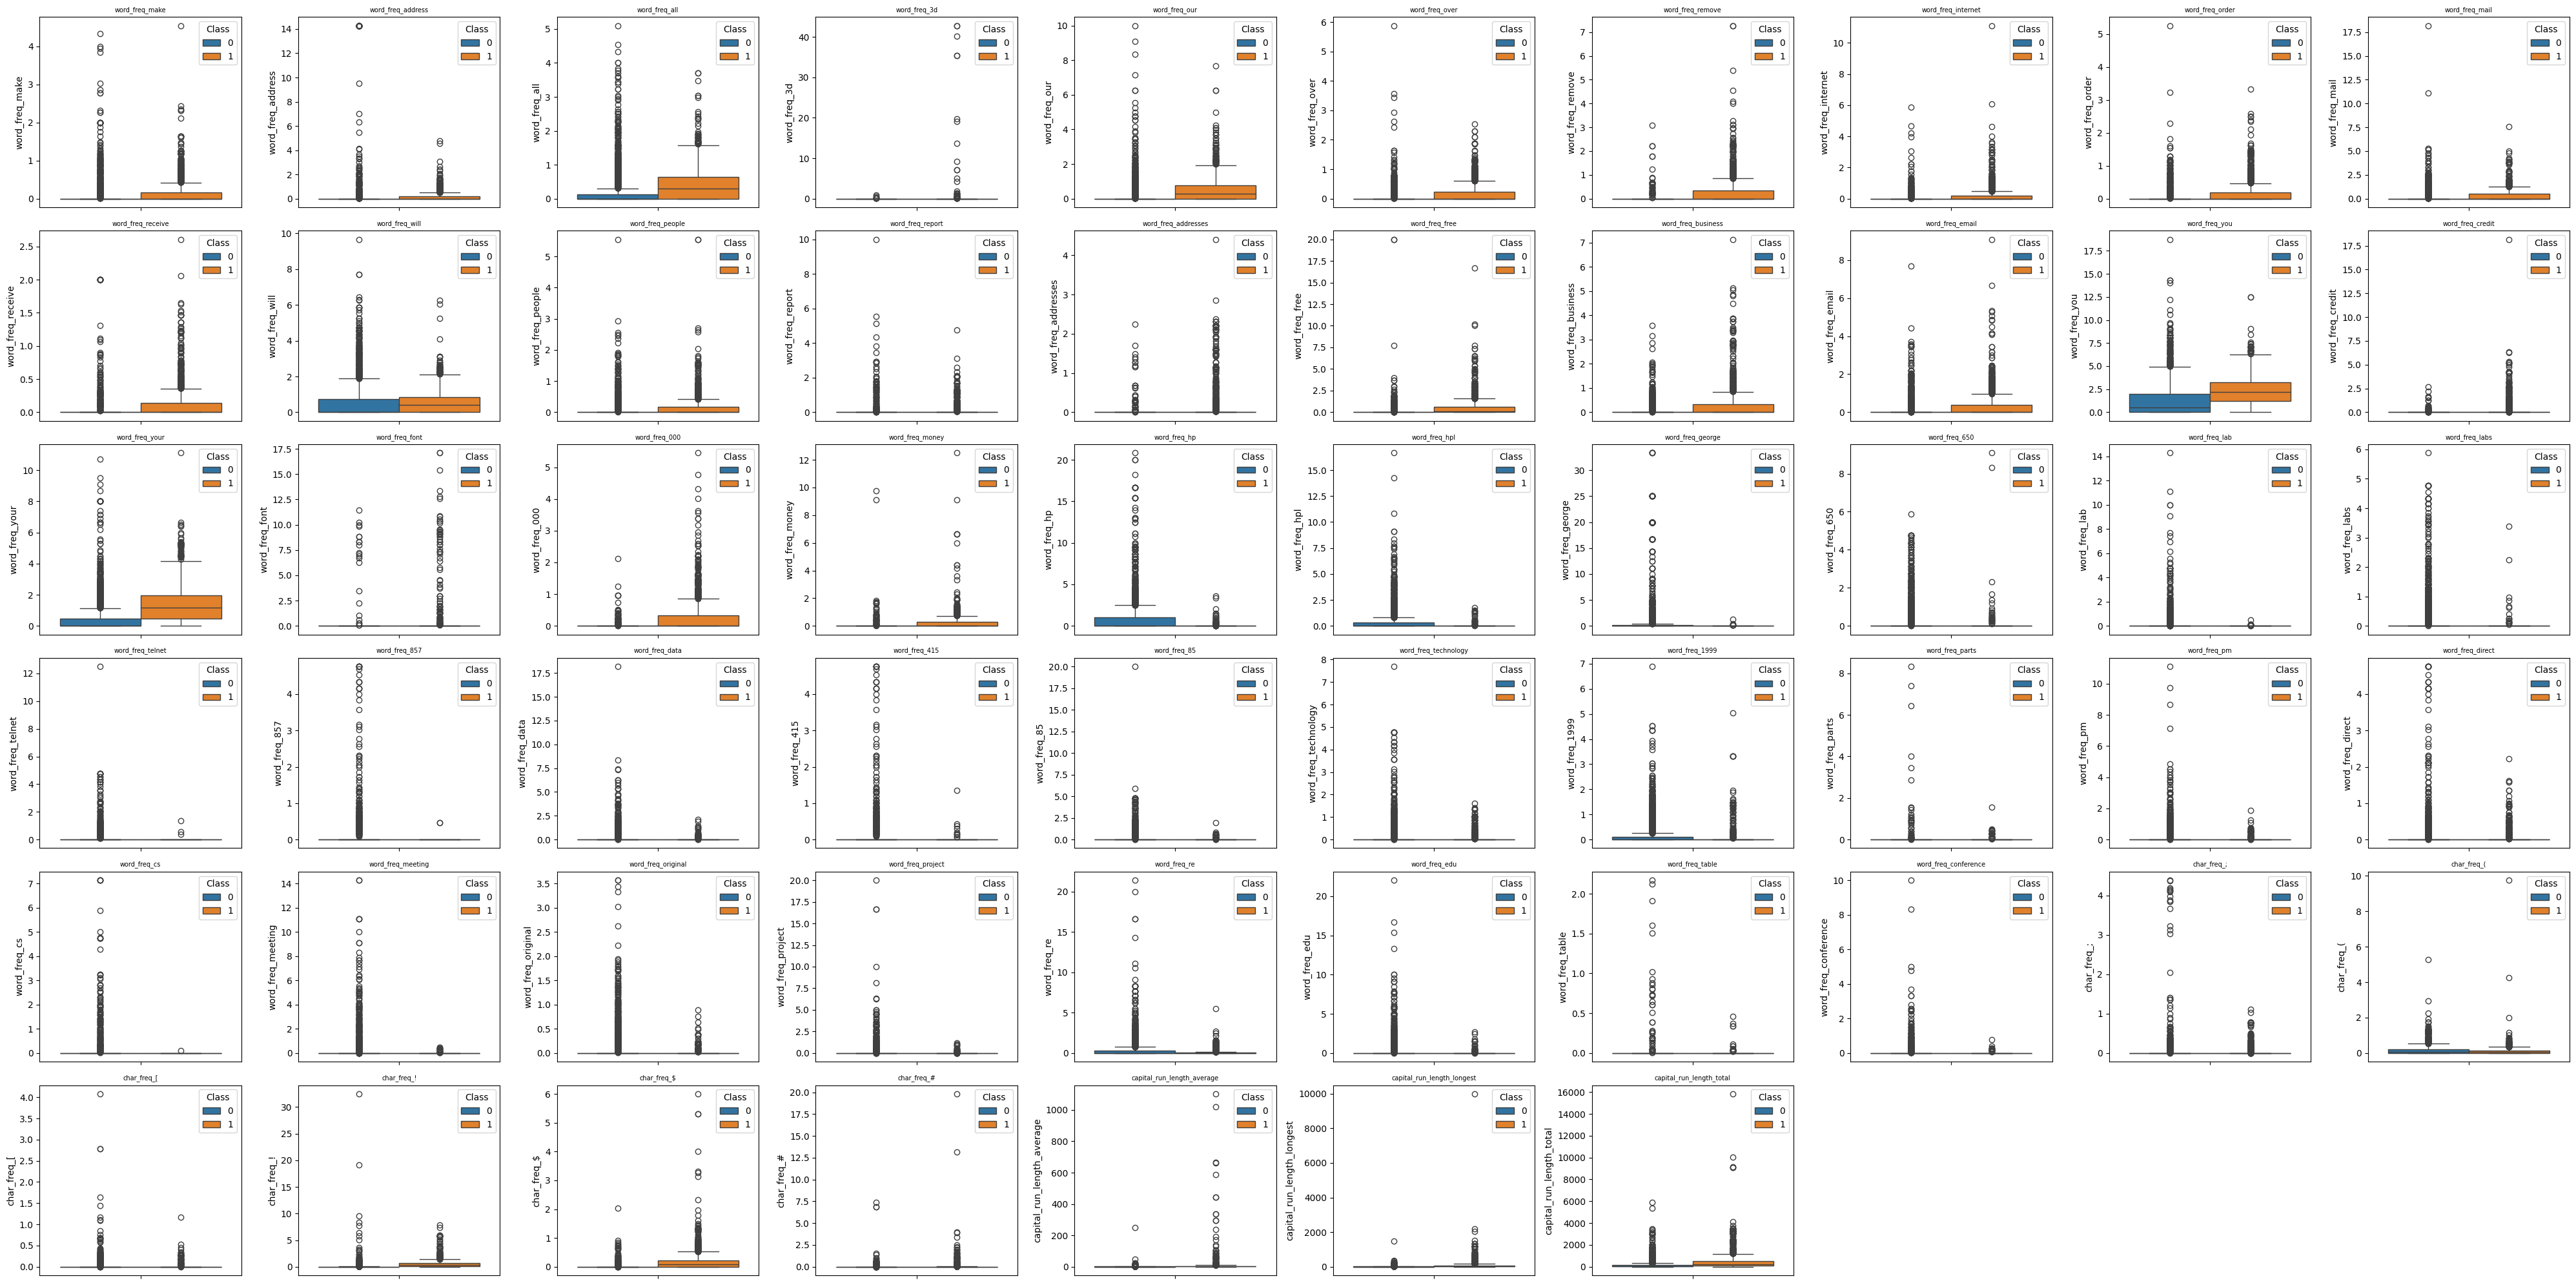

In [8]:
fig, axes = plt.subplots(6, 10, figsize=(40, 20))
axes = axes.flatten()

for i, col in enumerate(X.columns):
    sns.boxplot(data=df, hue='Class', y=col, ax=axes[i])
    axes[i].set_title(col, fontsize=7)
    axes[i].set_xlabel('')

for j in range(len(X.columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Per identificare le feature più discriminanti, senza mettersi a guardare i vari boxplot uno a uno, abbiamo calcolato per ciascuna la differenza assoluta tra le mediane delle due classi, normalizzata per la deviazione standard. Abbiamo scelto la mediana invece della media perché le distribuzioni delle feature sono fortemente asimmetriche e zero-inflated, come evidenziato dai boxplot. La normalizzazione per la deviazione standard rende il valore confrontabile tra feature con scale diverse

In [9]:
# Calcolo separazione per ogni feature
separations = []
for col in X.columns:
    med_spam = df.loc[df['Class'] == 1, col].median()
    med_nonspam = df.loc[df['Class'] == 0, col].median()
    std = df[col].std() + 1e-9 #Viene sommato + 1e-9 per evitare il caso in cui la devizione standard sia zero, cioè quando tutti i valori sono uguali, e la division successiv dia errore
    sep = abs(med_spam - med_nonspam) / std
    separations.append((col, sep))

sep_df = pd.DataFrame(separations, columns=['Feature', 'Separation'])
sep_df = sep_df.sort_values('Separation', ascending=False).reset_index(drop=True)

print(sep_df.to_string())

                       Feature  Separation
0               word_freq_your    0.990998
1                word_freq_you    0.940590
2                word_freq_all    0.595069
3               word_freq_will    0.499014
4                word_freq_our    0.431219
5                  char_freq_!    0.405801
6                  char_freq_$    0.325359
7     capital_run_length_total    0.230891
8               word_freq_free    0.169534
9   capital_run_length_longest    0.143670
10  capital_run_length_average    0.055595
11                 char_freq_(    0.001849
12          word_freq_internet    0.000000
13             word_freq_order    0.000000
14            word_freq_report    0.000000
15           word_freq_receive    0.000000
16              word_freq_mail    0.000000
17          word_freq_business    0.000000
18         word_freq_addresses    0.000000
19            word_freq_remove    0.000000
20              word_freq_over    0.000000
21            word_freq_people    0.000000
22         

Le fature più discriminanti sono: **word_freq_your**, **word_freq_you**, **word_freq_all**, **word_freq_will**, **word_freq_our**, **char_freq_!**

### Analisi delle relazioni tra le feature più discriminanti



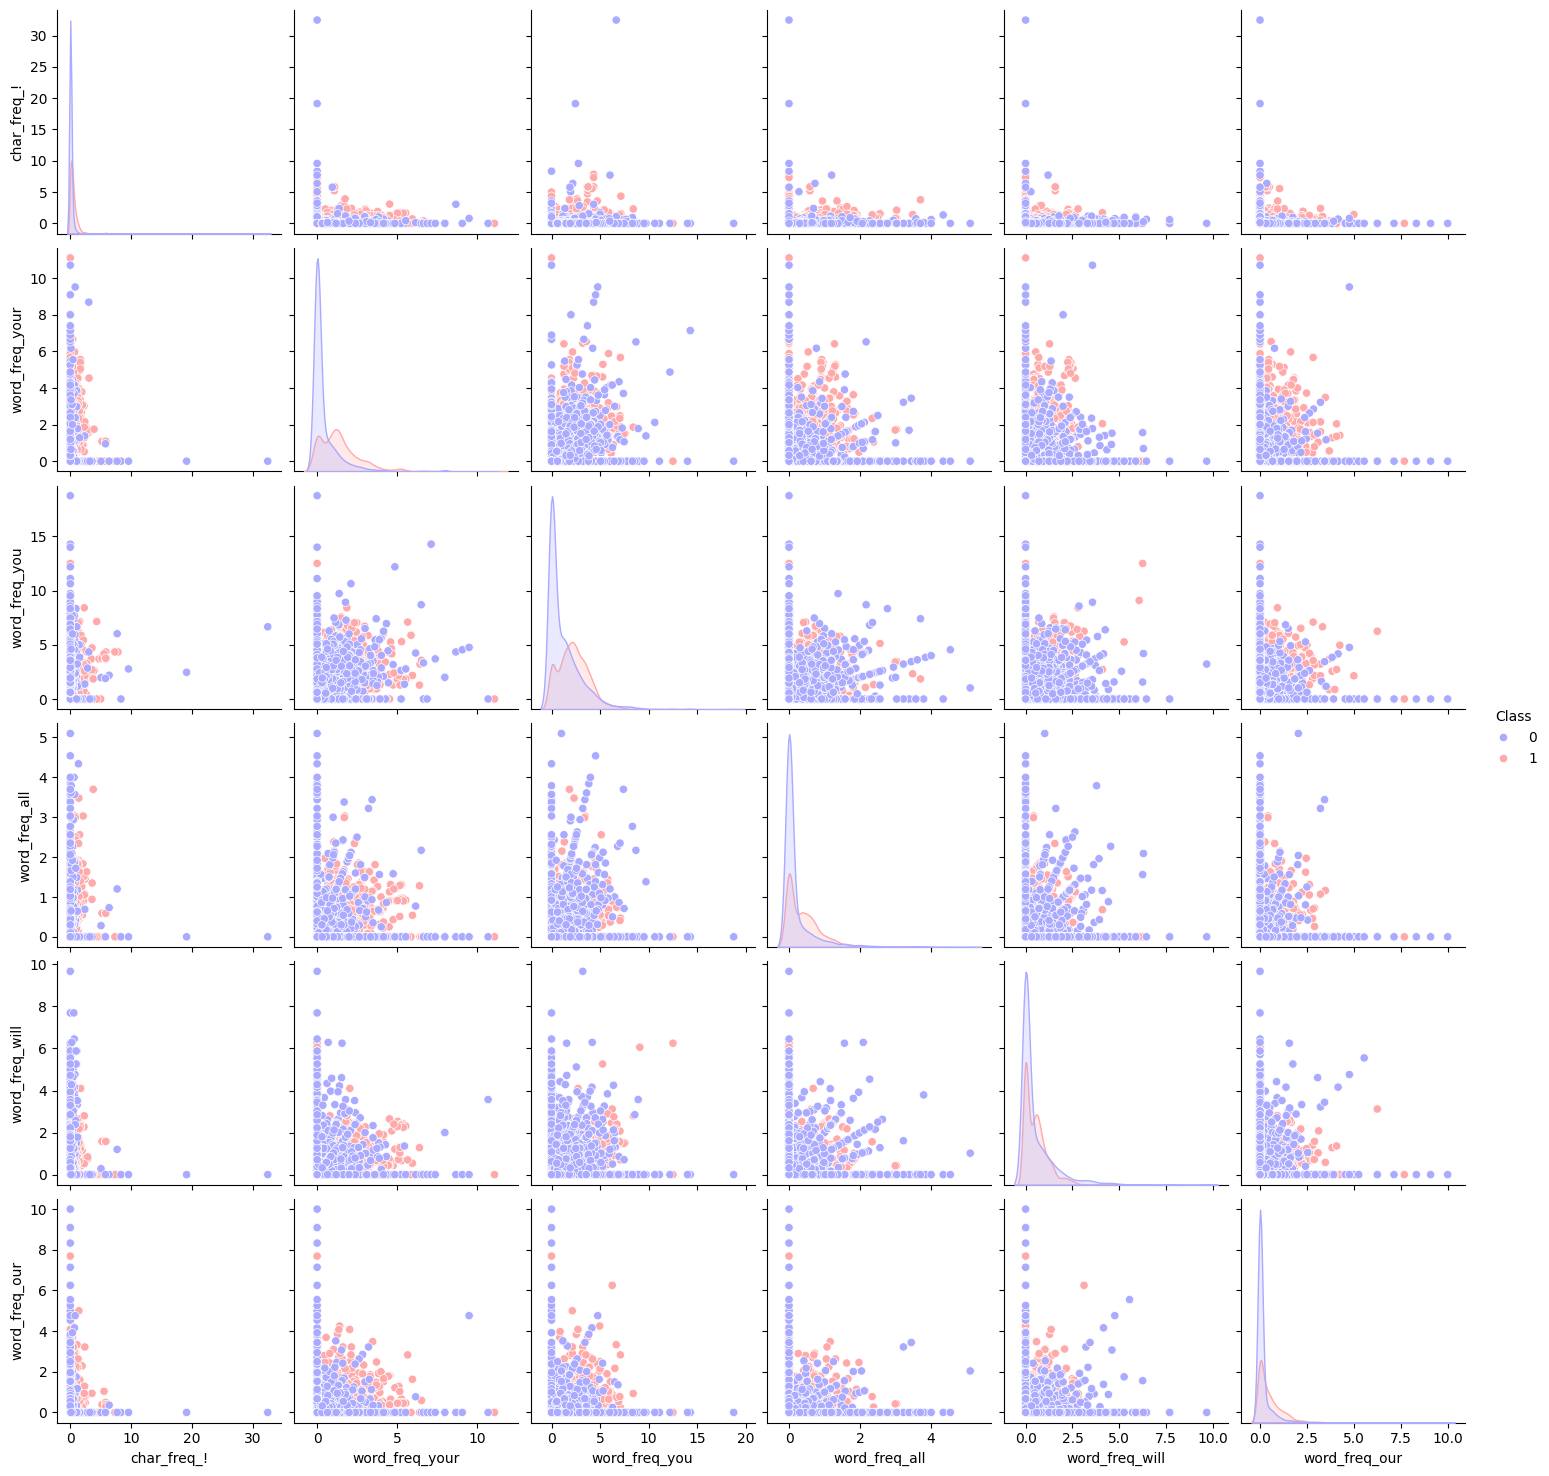

In [10]:
feature_chiave = ['char_freq_!', 'word_freq_your', 'word_freq_you', 'word_freq_all', 'word_freq_will', 'word_freq_our','Class']
sns.pairplot(df[feature_chiave], hue='Class', palette='bwr', diag_kind='kde')
plt.show()

Il pair plot evidenzia relazioni non lineari tra le feature, confermando l'inadeguatezza del coefficiente di Pearson. La sovrapposizione parziale tra le classi suggerisce che la classificazione richiede l'utilizzo di più feature

### Matrice di Correlazione di Spearman


Come visto in precedenza, abbiamo decisio di usare il coefficiente di Spearman (e non Pearson) per alcuni motivi:
1.   **Grande numero di 0 all'interno delle feature:** L'indice di Spearman lavora sui ranghi anziché sui valori assoluti. Di conseguenza  ai  valori pari a 0 vengono assegnati i ranghi più bassi, mentre ai valori non nulli vengono assegnati ranghi via via più elevati in base alla loro grandezza. Infine, il coefficiente viene calcolato applicando la formula di Pearson sull'intera distribuzione dei ranghi ottenuti
2.   **Presenza di outliers:** dato che nel dataset è presente una forte variazione dei dati (da valori molto grandi a estremamente piccoli), Spearman risulta più robuto rispetto a Pearson (che è più sensibile alla distanza tra i dati)
3.  **Relazioni non lineari:** il coefficiente di Pearson valuta esclusivamente la presenza di una relazione lineare. L'indice di Spearman, invece, converte i dati in ranghi per misurare la monotonicità della relazione; in questo modo, è in grado di rilevare se due variabili si muovono nella stessa direzione in modo consistente



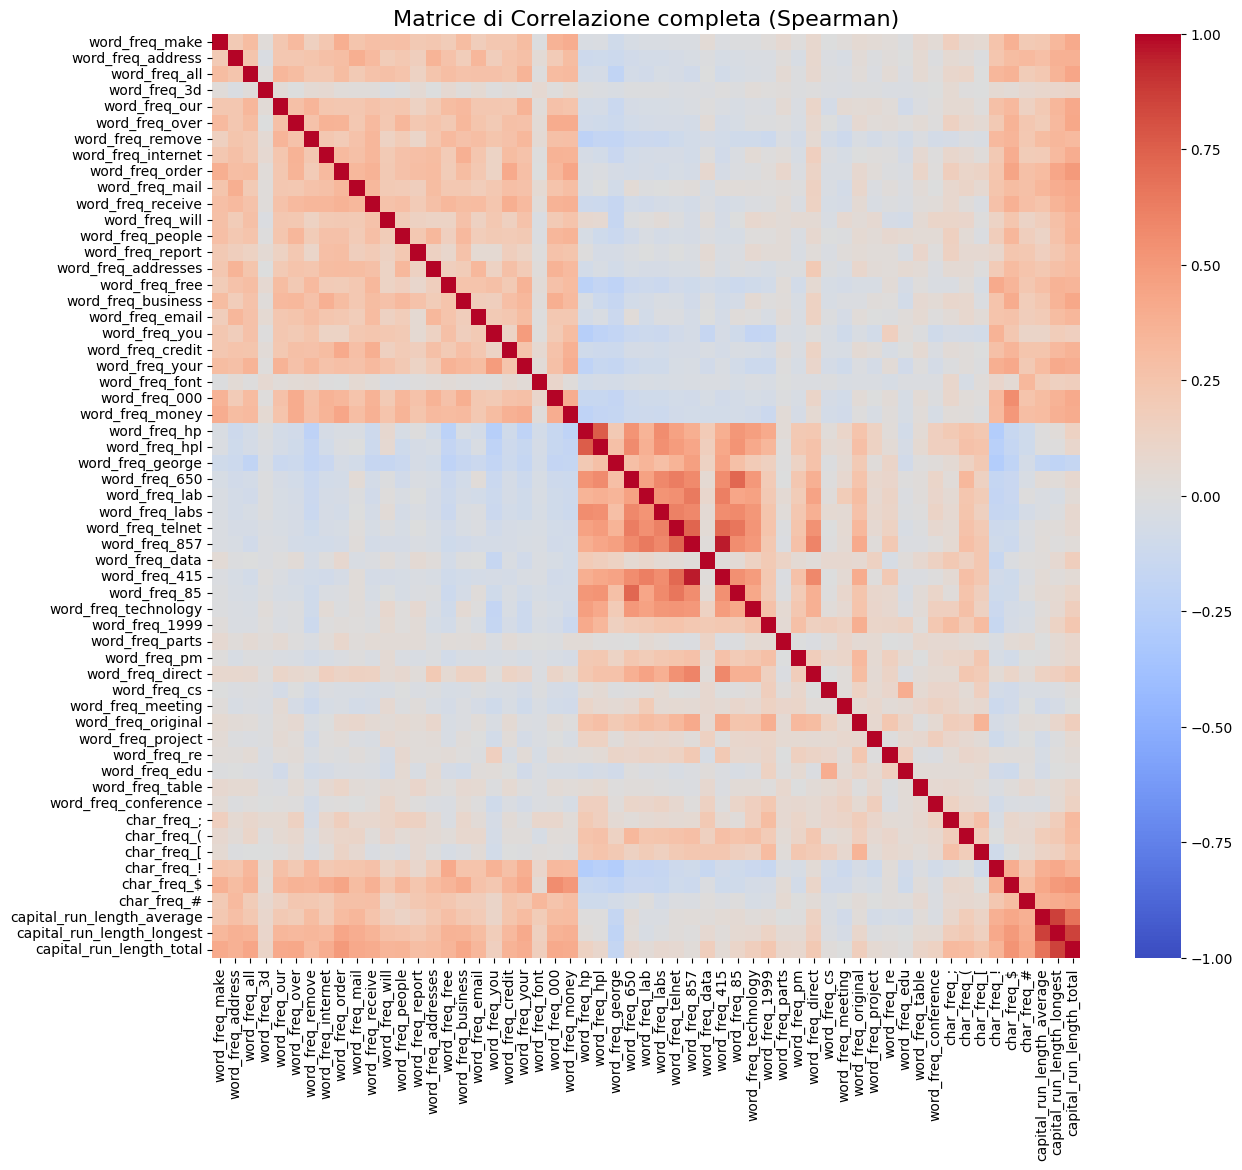

In [11]:
correlation_matrix = X.corr(method='spearman') # Coefficiente di correlazione di Spearman

plt.figure(figsize=(14, 12))

sns.heatmap(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False)

plt.title('Matrice di Correlazione completa (Spearman)', fontsize=16)
plt.show()

Di seguito mostriamo la matrice di correlazione con la varibile target, vengono ordinati in modo decrescente i valori di correlazione di Spearman

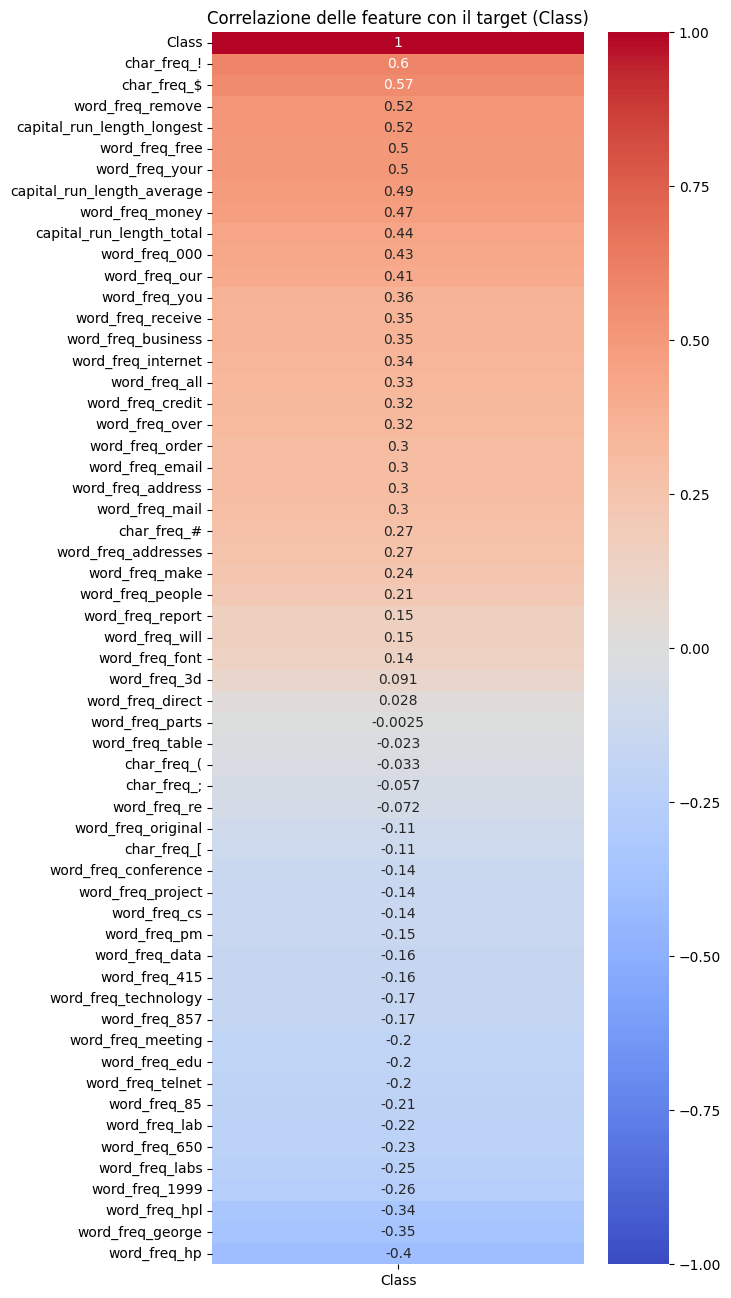

In [12]:
correlation_target_map = df.corr(method='spearman')[['Class']].sort_values(by='Class', ascending=False)
plt.figure(figsize=(6, 16))
sns.heatmap(correlation_target_map, vmin=-1, vmax=1, annot=True, cmap='coolwarm')
plt.title('Correlazione delle feature con il target (Class)')
plt.show()

Mostriamo le aree di maggior interesse, quelle dove sono presenti le variabili più correlate, da più vicino per una migliore comprensione

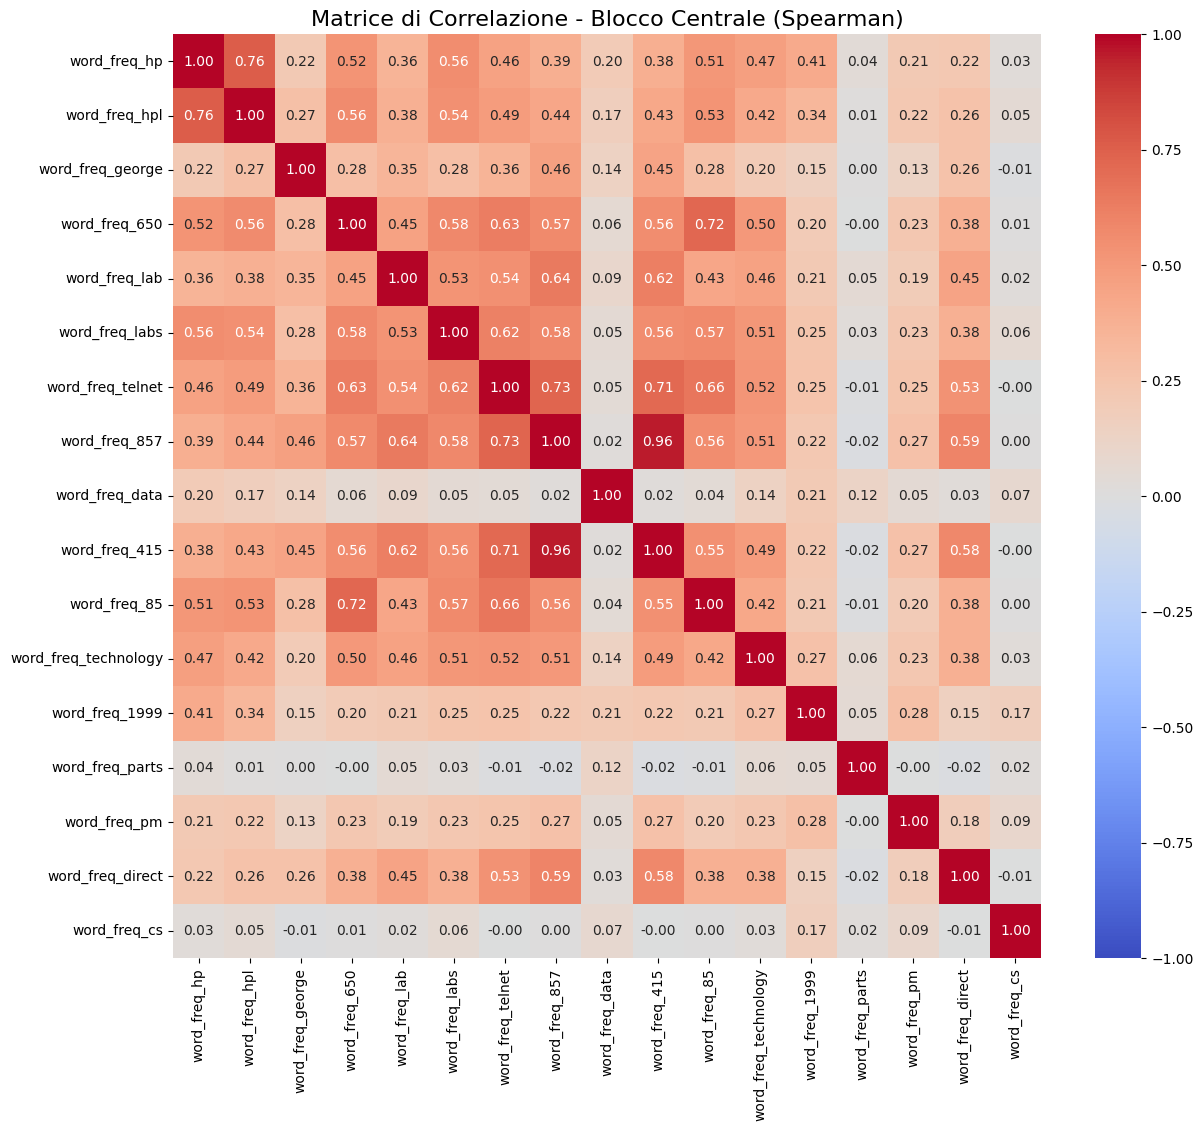

In [13]:
center_cols = X.loc[:, 'word_freq_hp':'word_freq_cs'].columns

correlation_matrix_subset = X[center_cols].corr(method='spearman') # Coefficiente di correlazione di Spearman

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix_subset, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title('Matrice di Correlazione - Blocco Centrale (Spearman)', fontsize=16)
plt.show()

In questa prima sottomatrice notiamo una fortissima correlazione reciproca tra le tre seguenti feature:
- word_freq_857 e word_freq_415, correlazione $r = 0.96$
- word_freq_hp e word_freq_hpl con correlazione $r = 0.76$

Per decidere chi tenere, andiamo a vedere chi ha l'associazione di Spearman più alta rispetto al target (Class):

- tra word_freq_857: $r_{\text{target}} = -0.170$ e word_freq_415: $r_{\text{target}} = -0.158$
- tra word_freq_hp: $r_{\text{target}} = -0.400$ e word_freq_hpl: $r_{\text{target}} = -0.342$

In questo caso le feature che rimuoveremo saranno:
- word_freq_415
- word_freq_hpl

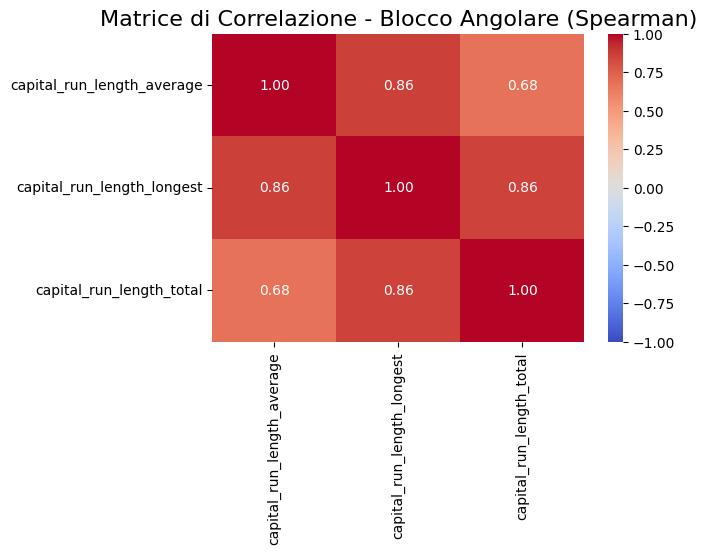

In [14]:
corner_cols = X.loc[:, ['capital_run_length_average', 'capital_run_length_longest', 'capital_run_length_total']].columns

correlation_matrix_subset = X[corner_cols].corr(method='spearman')

plt.figure(figsize=(6, 4))
sns.heatmap(correlation_matrix_subset, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title('Matrice di Correlazione - Blocco Angolare (Spearman)', fontsize=16)
plt.show()

In questa sottomatrice notiamo una fortissima correlazione reciproca tra le tre seguenti feature:
- capital_run_length_average e capital_run_length_longest, con correlazione $r = 0.86$
- capital_run_length_longest e capital_run_length_total, con correlazione  $r = 0.86$

Per decidere chi tenere, andiamo a vedere chi ha l'associazione di Spearman più alta rispetto al target (Class):
- capital_run_length_longest: $r_{\text{target}} = 0.515$
- capital_run_length_average: $r_{\text{target}} = 0.488$
- capital_run_length_total: $r_{\text{target}} = 0.444$

In questo caso le feature che rimuoveremo saranno:
- capital_run_length_average
- capital_run_length_total

### Analisi del P-value

Calcoliamo il p-value con spearman. Spearman, a differenza di Pearson, prima calcola i ranghi, dove ogni valore viene sostituito con la sua posizione nell'ordinamento e i valori uguali ricevono il rango medio delle loro posizioni, poi applica la formula classica di Pearson, ma sui ranghi invece che sui valori originali.

- r_s è il valore di correlazione di Spearman tra la colonna e il target;
- p_s è il p-value del valore di correlazione della colonna con il target, e indica se la correlazione è dovuta al caso o meno.

In [15]:
print(f"{'Feature':<30} {'Spearman r':>12} {'p Spearman':>12}")
print("-" * 80)
for col in X.columns:
    r_s, p_s = stats.spearmanr(df[col], df['Class'])
    print(f"{col:<30} {r_s:>12.3f} {p_s:>12.4f}")

Feature                          Spearman r   p Spearman
--------------------------------------------------------------------------------
word_freq_make                        0.241       0.0000
word_freq_address                     0.298       0.0000
word_freq_all                         0.333       0.0000
word_freq_3d                          0.091       0.0000
word_freq_our                         0.409       0.0000
word_freq_over                        0.319       0.0000
word_freq_remove                      0.519       0.0000
word_freq_internet                    0.344       0.0000
word_freq_order                       0.301       0.0000
word_freq_mail                        0.297       0.0000
word_freq_receive                     0.355       0.0000
word_freq_will                        0.148       0.0000
word_freq_people                      0.213       0.0000
word_freq_report                      0.150       0.0000
word_freq_addresses                   0.265       0.0000
word_fr

Il p-value misura la probabilità che la correlazione osservata sia puramente casuale. Utilizzando la soglia standard di significatività alfa ($\alpha = 0.05$), individuiamo le variabili che devono essere rimosse dal dataset poiché non hanno un legame statisticamente attendibile con il target: <br>
- word_freq_parts con un p-value = 0.8640
- word_freq_table con un p-value = 0.1242
- word_freq_direct con un p-value = 0.0564

Tra le variabili con ($\alpha < 0.05$), l'indice di spearman ci permette di individuare:
- char_freq_! ($0.598$), char_freq_\$ ($0.566$), word_freq_remove ($0.519$) e capital_run_length_longest ($0.515$) come forti indicatore di Spam
- word_freq_hp ($-0.400$), word_freq_george ($-0.354$) e word_freq_hpl ($-0.342$) come forti indicatori di Not Spam

## Fase preprocessing

### Rimozione delle feature

Abbiamo deciso di rimuovere le feature identificate durante l'analisi esplorativa.

In [16]:
features_to_drop = [
    'word_freq_table',
    'word_freq_hpl',
    'word_freq_parts',
    'word_freq_direct',
    'word_freq_415',
    'capital_run_length_average',
    'capital_run_length_total'
]

# Creazione del dataset ridotto
X_cleaned = X.drop(columns=features_to_drop)
print(f"Numero di feature residue: {X_cleaned.shape[1]}")

Numero di feature residue: 50


### Divisione in set

Il dataset viene diviso in due parti 80% per la parte di training e 20% per la parte di test, il parametro 'stratify=y' permette di avere la stessa proporzione di valori della classe target in entrambi i set.

Abbiamo diviso il dataset anche sui dati 'cleaned' per allenare il modello SVM.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y.iloc[:,0], test_size=0.2, random_state=19, stratify=y)

X_train_cleaned, X_test_cleaned, y_train, y_test = train_test_split(
    X_cleaned, y.iloc[:,0], test_size=0.2, random_state=19, stratify=y)

### Standardizzazione

In questo blocco standardizziamo i dati con StandardScaler(), che permette di avere per ogni feature una media pari a 0 e una deviazione standard (e varianza) pari a 1, attraverso la funzione fit_trasform:<br>
 dove on 'fit', lo scaler impara la media e la deviazione standard di X_train, mentre con 'transform', applica la formula matematica per scalare i dati di X_train. Mentre sui dati di test applico solo .trasform() utilizzando medi e varianza calcolati sui dati di train, cosi da non avere data leakage.

In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_cleaned)

X_test_scaled = scaler.transform(X_test_cleaned)

Se standardizzassimo l'intero dataset tutto insieme prima di dividerlo, lo StandardScaler calcolerebbe la media e la deviazione standard usando anche le informazioni del Test Set. In questo modo, quando alleneremo la SVM, il modello conoscerebbero indirettamente informazioni sul Test Set, provocando cosi un Data Leakage.
Dividendo prima il dataset, ci assicuriamo che il Test Set rimanga completamente isolato.

## Fase di training

Durante la fase di Training il Decision Tree verrà allenato su X_train (dataset completo), mentre
SVM viene allenato su X_train_scaled (dataset senza le feature
ridondanti e standardizzato).

Il **Decision Tree** esegue selezione delle feature in modo implicito, scegliendo ad   ogni split quella che massimizza il criterio di purezza. Dunque risulta più robusto a feature ridondanti o non informative. Non è necessario usare la standardzzazione per il DT perchè non lavora sulle distanze, ma individua la soglia ottimale per suddividere i dati.<br>
L'**SVM**, al contrario, considera tutte le feature nel calcolo del margine. Quindi migliora la sua performance con una rimozione delle feature ridondanti e con una standardizzazione.

###Modello Baseline

Modello "dummy" che predice sempre la classe maggioritaria (0). Lo usiamo come base di valutazione per i modelli, risultati peggiori di questo classificatore base non possono fare.

Il modello baseline crea un array della lunghezza del vettore del test reale e lo riempe di zeri, come se avesse predetto sempre la classe 0.

In [19]:
y_pred_baseline = np.zeros(y_test.shape)

### Decision tree

Utilizziamo la Grid Search con la Cross-Validation per individuare il valore ottimale di max_depth, in un range da 1 a 20. Questo processo controlla la complessità dell'albero, bilanciando la profondità per evitare fenomeni di underfitting o overfitting.

GridSearchCV allena e valuta l'albero per ogni valore di max_depth usando la 5-fold cross-validaton (cv=5) per stimare l'accuratezza senza usare il set di test.

È stato usato il parametro n_jobs=-1 per velocizzare la ricerca, infatti permette di parallerizzarla su tutti i core disponibili.

Essendo che il max_depth migliore è 18, non mostriamo l'albero di decisione perchè illeggibile e poco utile.

In [20]:
param_grid = {
    'max_depth': list(range(1, 21))
}

base_dt = DecisionTreeClassifier(random_state=42, min_samples_split=2, class_weight='balanced')

grid_search_dt = GridSearchCV(
    estimator=base_dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Esegue la ricerca solo sul training set
grid_search_dt.fit(X_train, y_train)

print("Miglior max_depth:", grid_search_dt.best_params_)
print("Miglior accuratezza in CV:", grid_search_dt.best_score_)

# Usa il miglior modello trovato per predire sul test set
dt = grid_search_dt.best_estimator_

Miglior max_depth: {'max_depth': 18}
Miglior accuratezza in CV: 0.9255434782608696


### SVM

Abbiamo scelto un kernel lineare per il SVM, che cerca una linea retta, nel nostro caso un iperpiano perchè abbiamo più dimensioni, che separa al meglio i punti di Not Spam e Spam.

È stata fatta una ricerca del valore migliore dell'iperparametro C attraverso Grid Search.
Come per il valore *max_depth* nel DT, è stata validata solo sul training set tramite 5-fold cross-validation (cv=5).

È stato valutato il valore migliore di C, parametro che permette di controllare il trade-off
tra il margine largo e la classificazione corretta dei punti di training. Se C è troppo basso,
il margine sarà maggiore e si rischia un underfitting; se C è troppo alto, il margine si restringe troppo rischiando
l'overfitting.

È stata usata una scala logaritmica (0.01, 0.1, 1, 10, 100) perché C è un iperparametro che
agisce in modo moltiplicativo, non lineare, sulla regolarizzazione.

In [21]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

svc_lin = SVC(kernel='linear', class_weight='balanced', random_state=42, probability=True)

grid_search_svm = GridSearchCV(
    estimator=svc_lin,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Esegue la ricerca solo sul training set
grid_search_svm.fit(X_train_scaled, y_train)

print("Miglior C:", grid_search_svm.best_params_)
print("Miglior accuratezza in CV:", grid_search_svm.best_score_)

# Usa il miglior modello trovato per predire sul test set
svm = grid_search_svm.best_estimator_

Miglior C: {'C': 10}
Miglior accuratezza in CV: 0.9326086956521739


## Risultati

### Baseline

Come previsto, il modello ottiene un accuratezza del 61%, che corrisponde esattamente alla proporzione della classe maggioritaria 0 (non spam).
Il modello non riconosce mai lo spam, e predice sempre 0.
Qualsiasi altro modello, Decison Tree e SVM, devono quindi superare non solo l'accuracy, ma sopratutto la recall e l'f1-score per mostrare che hanno imparato a distinguere le classi.

              precision    recall  f1-score   support

           0       0.61      1.00      0.75       558
           1       0.00      0.00      0.00       363

    accuracy                           0.61       921
   macro avg       0.30      0.50      0.38       921
weighted avg       0.37      0.61      0.46       921



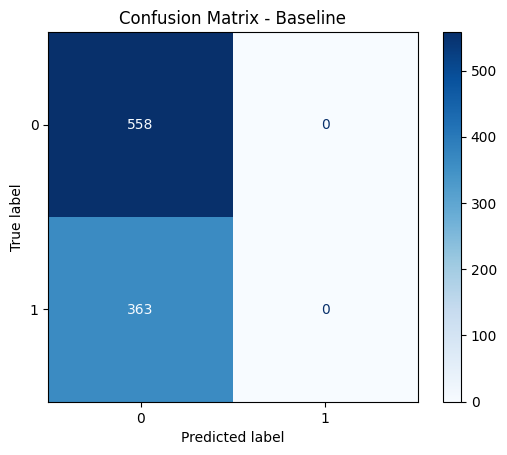

In [22]:
cm = confusion_matrix(y_test, y_pred_baseline)

print(classification_report(y_test, y_pred_baseline, zero_division=0))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Baseline")
plt.show()

### Decision Tree

Come si puo vedere dai risultati, l'albero di decisione mostra ottime capacità predittive, raggiungendo un'accuratezza complessiva del 91% sul test set.

Dall'analisi della matrice di confusione emergono i seguenti dettagli:

- True Negative: il modello identifica correttamente 522 email legittime su 558.

- True Positive: il modello intercetta correttamente 318 email di spam su 363.

- False Positive: sono le email legittime scambiate per spam, il modello "sbaglia" 36 volte.

- False Negative: sono le eamil di spam scambaite per legittime, il modello "sbaglia" 45 volte.

L'F1-Score bilanciato, con un valore del 93% per la classe 0 e del 89% per la classe 1, conferma che il modello gestisce bene lo sbilanciamento originario del dataset.

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       558
           1       0.90      0.88      0.89       363

    accuracy                           0.91       921
   macro avg       0.91      0.91      0.91       921
weighted avg       0.91      0.91      0.91       921



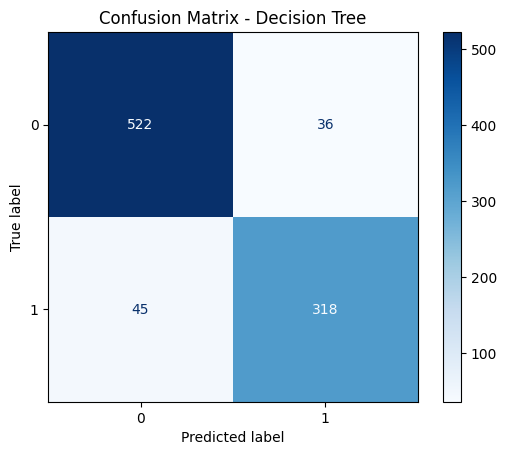

In [23]:
y_pred_dt = dt.predict(X_test)

print(classification_report(y_test, y_pred_dt))
cm = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Decision Tree")
plt.show()

### SVM

La SVM con kernel lineare supera le prestazioni dell'albero di decisione, raggiungendo un'accuratezza complessiva del 93%, con un incremento del 2% rispetto al Decision Tree.

Analizzando la matrice di confusione otteniamo i seguenti risultati:

- True Negative: il modello identifica corettamente 524 email legittime su 558.

- True Positive: il modello identifica correttamente 328 email di spam, 10 in piu del decision tree

- False Positive: le email legittime scambiate erroneamente per spam scendono a 34.

- False Negative: anche le email di spam scambiate per legittime diminuiscono a 35, rispetto ai 45 del decision tree.

I valori di F1-Score, con il 94% per la classe 0 e del 90% per la classe 1,confermano che il modello gestisce bene lo sblianciamento dei dati, portando dei risultati migliori rispetto al decision tree.

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       558
           1       0.91      0.90      0.90       363

    accuracy                           0.93       921
   macro avg       0.92      0.92      0.92       921
weighted avg       0.93      0.93      0.93       921



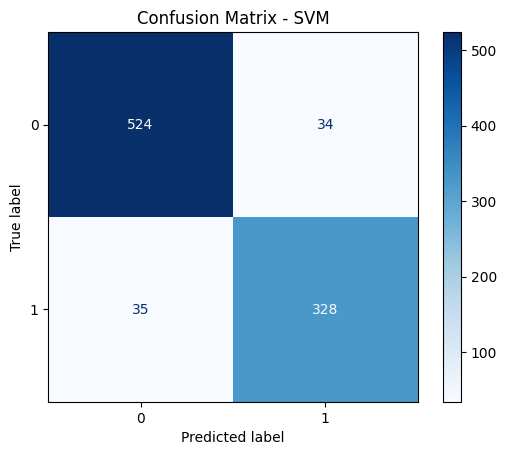

In [24]:
y_pred_svm = svm.predict(X_test_scaled)

print(classification_report(y_test, y_pred_svm))

cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.show()

### Curva di ROC

La ROC curve mostra il tradeoff tra trovare più email Spam e fare meno errori sulle email legittime al variare della soglia. Mentre l'AUC sintetizza questro tradeoff in un numero unico, dove più il valore dell'AUC è vicino a 1, migliore è il modello.

La ROC curve conferma come modello migliore l'SVM rispetto al Decision Tree, avendo una AUC di 0.97 per la SVM e del 0.90 per il Decision Tree.

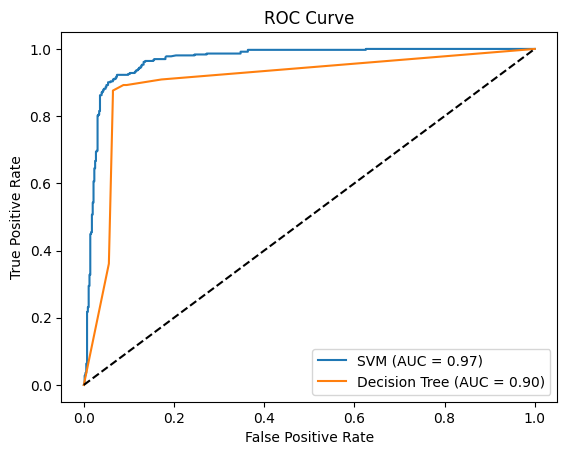

In [25]:
#'predict_proba' calcola le probabilità con i valori calcolati dal Platt Scaling (attivato con probability=True), che serve per convertire
# le distanze geometriche dei punti dall'iperpiano in probabilità, da 0 a 1
y_svm_pred_prob = svm.predict_proba(X_test_scaled)[:, 1]

# 'predict_proba' calcola la probabilità basandosi nativamente sulla frequenza dei campioni
y_dt_pred_prob = dt.predict_proba(X_test)[:, 1]

fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_svm_pred_prob)
auc_svm = roc_auc_score(y_test, y_svm_pred_prob)

fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_dt_pred_prob)
auc_dt = roc_auc_score(y_test, y_dt_pred_prob)

plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm:.2f})')
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.2f})')

# Disegna la linea diagonale tratteggiata del classificatore casuale
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend()
plt.show()

### Tempo di training

Dai risultati, si può notare come il Decision Tree sia nettamente più veloce rispetto alla SVM durante la fase di training.

Il motivo di questa differenza di tempo si basa sull'algoritmo di classificazione dei due modelli:
*   Il Decision Tree usa un algoritmo basato sulle soglie, esegue split sul dataset basandosi su di esse. Essendo un'operazione basilare, il tempo di esecuzione è pari a *O(m · n log n)*, dove n è il numero di campioni, mentre m è il numero di feature.
*   La SVM, usando un algoritmo che punta all'individuazione dell'iperpiano di margine massimo, deve risolvere un problema di ottimizzazione quadratica, comportando un tempo di computazione compreso tra O(n² ) e O(n³). La SVM è quindi più sensibile alla crescita del valore *n*.

Su un dataset di dimensioni contenute come Spambase (~4600 righe) questa differenza non è limitante, ma diventerebbe un fattore rilevante nella scelta del modello su dataset più grandi o in scenari che richiedono un ri-allenamento frequente.

In [26]:
start_time = time()
dt.fit(X_train, y_train)
end_time = time()
dt_training_time = end_time - start_time

start_time = time()
svm.fit(X_train_scaled, y_train)
end_time = time()
svm_training_time = end_time - start_time

print(f'Tempo di training Decision Tree: {dt_training_time:.4f} secondi')
print(f'Tempo di training SVM: {svm_training_time:.4f} secondi')

Tempo di training Decision Tree: 0.0917 secondi
Tempo di training SVM: 13.6319 secondi
